# Task 3 – From touchpoint to lasting customer

What the three aggregated models show. The models and the definitions (conversion, customer, customer journey,
attribution, complete) are in the [README](../README.md#task-3--kpi--customer-level-aggregation). Before running:
`cd dbt && dbt build`.

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Shared by the notebooks, see notebooks/common/
from common import bar_chart, configure_plotly, query

configure_plotly()


def wilson_interval(successes: pd.Series, total: pd.Series, z: float = 1.96) -> pd.DataFrame:
    """95 % interval of a rate (Wilson score), in percent: where the true rate plausibly lies."""
    successes, total = successes.astype(float), total.astype(float)
    rate = successes / total
    centre = (rate + z**2 / (2 * total)) / (1 + z**2 / total)
    half_width = (
        z * np.sqrt(rate * (1 - rate) / total + z**2 / (4 * total**2)) / (1 + z**2 / total)
    )
    return pd.DataFrame(
        {"low_pct": 100 * (centre - half_width), "high_pct": 100 * (centre + half_width)}
    ).round(1)

## Summary

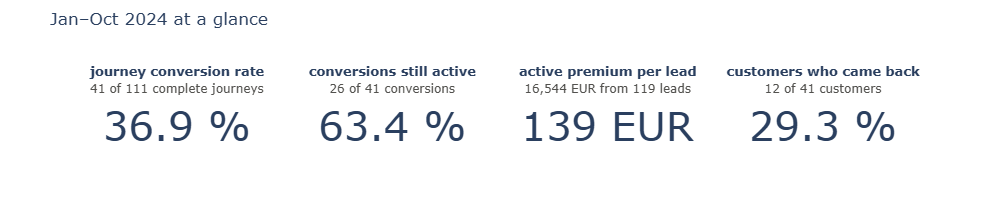

In [2]:
kpis = query("""
    with journeys as (
        select
            count_if(is_complete) as complete_journeys,
            count_if(is_converted) as converted_journeys
        from agg_customer_journeys
    ),

    conversions as (
        select
            count(*) as conversions,
            count_if(contract_status = 'active') as active_conversions
        from mart_lead_conversions
        where is_last_touch
    ),

    value as (
        select
            sum(leads) as leads,
            sum(active_premium) as active_premium
        from agg_lead_conversions_monthly
    ),

    customers as (
        select
            count_if(conversions > 0) as customers,
            count_if(returned_after_contract) as came_back
        from agg_customers
    )

    select *
    from journeys
    cross join conversions
    cross join value
    cross join customers
""").iloc[0]

tiles = [
    (
        "journey conversion rate",
        100 * kpis["converted_journeys"] / kpis["complete_journeys"],
        " %",
        f"{kpis['converted_journeys']:.0f} of {kpis['complete_journeys']:.0f} complete journeys",
    ),
    (
        "conversions still active",
        100 * kpis["active_conversions"] / kpis["conversions"],
        " %",
        f"{kpis['active_conversions']:.0f} of {kpis['conversions']:.0f} conversions",
    ),
    (
        "active premium per lead",
        kpis["active_premium"] / kpis["leads"],
        " EUR",
        f"{kpis['active_premium']:,.0f} EUR from {kpis['leads']:.0f} leads",
    ),
    (
        "customers who came back",
        100 * kpis["came_back"] / kpis["customers"],
        " %",
        f"{kpis['came_back']:.0f} of {kpis['customers']:.0f} customers",
    ),
]

fig = go.Figure()
for column, (label, value, unit, caption) in enumerate(tiles):
    caption_html = f"<span style='font-size:12px;color:#52514e'>{caption}</span>"
    fig.add_trace(
        go.Indicator(
            mode="number",
            value=float(value),
            number={
                "suffix": unit,
                "valueformat": ".1f" if unit == " %" else ",.0f",
                "font": {"size": 40},
            },
            title={"text": f"<b>{label}</b><br>{caption_html}", "font": {"size": 13}},
            domain={"row": 0, "column": column},
        )
    )
fig.update_layout(
    title="Jan–Oct 2024 at a glance",
    grid={"rows": 1, "columns": 4},
    width=1000,
    height=200,
    margin={"t": 50, "b": 0},
)
fig.show()

**The story:** conversions come from customer journeys; the channels convert about equally often, but differ in
what lasts.
1. Over a third of the customer journeys convert, about three weeks after the first touch.
2. Customers with several touchpoints convert far more often.
3. Newsletter converts best, but the gaps between the channels are within the noise. Google opens journeys that
   other channels close.
4. Google's conversions last least, so a google lead is worth less than half of a newsletter lead.
5. Almost a third of the converted customers come back, most often for another product after about four weeks.

**How sure:** 119 leads and 41 conversions are few: one conversion moves a channel's rate by 2.5 points. 9 of 50
contracts cannot be attributed to a lead, and 6 journeys are still open. These are signals to watch, not proof.

## 1. How do customer journeys convert?

The journey table (`agg_customer_journeys`) has one row per customer journey. The five longest:

In [3]:
query("""
    select
        journey_id, customer_email, vertical, first_touch_date, touchpoints, path,
        is_converted, contract_status, days_to_convert, is_complete
    from agg_customer_journeys
    order by touchpoints desc, first_touch_date, journey_id
    limit 5
""")

,journey_id,customer_email,vertical,first_touch_date,touchpoints,path,is_converted,contract_status,days_to_convert,is_complete
0,1021,florian.fuchs@aon.at,haushalt,2024-03-10,2,google > direct,True,cancelled,23,True
1,1111,elias.winkler@outlook.com,leben,2024-07-20,2,google > newsletter,True,cancelled,23,True
2,1036,hannah.fuchs@gmx.at,auto,2024-01-05,1,newsletter,True,cancelled,30,True
3,1003,leon.hofer@gmx.at,auto,2024-01-12,1,google,True,active,4,True
4,1059,mia.gruber@gmail.com,auto,2024-01-15,1,google,True,cancelled,24,True


The conversion paths:

In [4]:
query("""
    select
        path as conversion_path,
        count(*) as conversions,
        median(days_to_convert) as median_days_to_convert
    from agg_customer_journeys
    where is_converted
    group by path
    order by conversions desc, conversion_path
""")

,conversion_path,conversions,median_days_to_convert
0,newsletter,16,21.5
1,direct,11,27.0
2,google,11,21.0
3,google > direct,1,23.0
4,google > newsletter,1,23.0
5,unknown,1,5.0


**Reading:** 41 of the 117 journeys ended in a conversion, 36.9 % of the 111 complete ones, 23 days after the
first touch (median). 39 conversion paths are a single touchpoint; the two longer ones both start with google and
end with direct or newsletter. (The path `unknown` is one lead whose channel is contradictory in the source.)

### 1.1 Do several touchpoints help to convert?

Two journeys are too few to tell. The customers give a clearer picture (`agg_customers`):

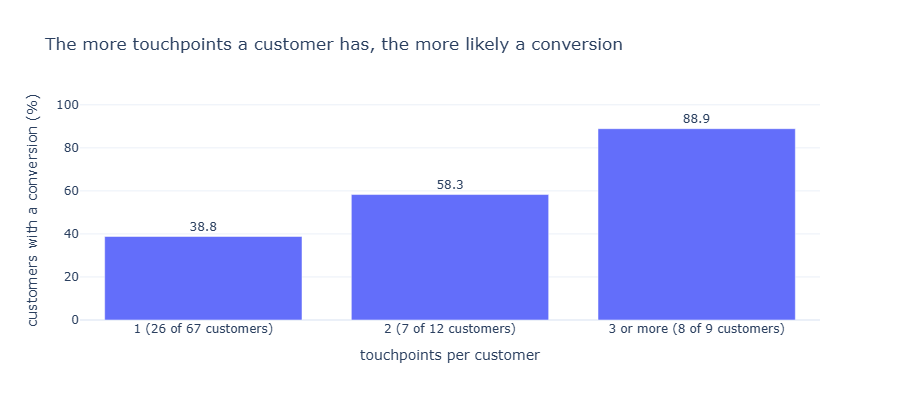

In [5]:
touchpoints_per_customer = query("""
    select
        case when leads >= 3 then '3 or more' else cast(leads as varchar) end as touchpoints,
        count(*) as customers,
        count_if(conversions > 0) as converted,
        round(100.0 * count_if(conversions > 0) / count(*), 1) as converted_pct
    from agg_customers
    group by 1
    order by 1
""")
touchpoints_per_customer["group"] = (
    touchpoints_per_customer["touchpoints"]
    + " ("
    + touchpoints_per_customer["converted"].astype(str)
    + " of "
    + touchpoints_per_customer["customers"].astype(str)
    + " customers)"
)

bar_chart(
    touchpoints_per_customer,
    x="group",
    y="converted_pct",
    title="The more touchpoints a customer has, the more likely a conversion",
    labels={"group": "touchpoints per customer", "converted_pct": "converted"},
    y_title="customers with a conversion (%)",
)

**Reading:** 38.8 % of the customers with one touchpoint converted, 58.3 % of those with two and 88.9 % of those
with three or more. That does not prove that touchpoints cause conversions: someone about to sign may simply
compare more. But it supports looking at the whole journey instead of a single lead.

## 2. Which channels convert, and which open or close journeys?

The monthly table (`agg_lead_conversions_monthly`) has one row per vertical, channel and lead month. The five
rows with the most leads:

In [6]:
query("""
    select *
    from agg_lead_conversions_monthly
    order by leads desc, lead_month, vertical, source
    limit 5
""")

,vertical,source,lead_month,leads,conversions,conversion_rate,active_premium,first_touch_conversions,first_touch_conversion_rate,first_touch_active_premium,is_complete
0,haushalt,newsletter,2024-04-01,6,2,0.333333,952.87,2,0.333333,952.87,True
1,leben,newsletter,2024-08-01,6,1,0.166667,0.0,0,0.0,0.0,True
2,haushalt,direct,2024-05-01,4,2,0.5,1000.03,2,0.5,1000.03,True
3,haushalt,direct,2024-10-01,4,1,0.25,0.0,1,0.25,0.0,False
4,leben,google,2024-03-01,3,2,0.666667,1356.74,2,0.666667,1356.74,True


The 119 leads spread over 68 rows, and 58 of those hold only one or two leads, so the rows are added up before
a rate is computed. Per channel, with the 95 % interval of the rate and the assists (touchpoints of a conversion
that are not its last touch) from the lead table:

In [7]:
channels = query("""
    with kpis as (
        select
            source as channel,
            sum(leads) as leads,
            sum(conversions) as conversions,
            round(100.0 * sum(conversions) / sum(leads), 1) as conversion_rate_pct,
            sum(first_touch_conversions) as first_touch_conversions,
            round(100.0 * sum(first_touch_conversions) / sum(leads), 1) as first_touch_rate_pct
        from agg_lead_conversions_monthly
        group by source
    ),

    assists as (
        select
            source as channel,
            count_if(is_converted and not is_last_touch) as assists
        from mart_lead_conversions
        group by source
    )

    select *
    from kpis
    left join assists using (channel)
    order by conversion_rate_pct desc, channel
""")
channels = channels.join(wilson_interval(channels["conversions"], channels["leads"]))
channels[
    [
        "channel",
        "leads",
        "conversions",
        "conversion_rate_pct",
        "low_pct",
        "high_pct",
        "first_touch_conversions",
        "first_touch_rate_pct",
        "assists",
    ]
]

,channel,leads,conversions,conversion_rate_pct,low_pct,high_pct,first_touch_conversions,first_touch_rate_pct,assists
0,unknown,2,1,50.0,9.5,90.5,1,50.0,0
1,newsletter,41,17,41.5,27.8,56.6,16,39.0,0
2,google,36,11,30.6,18.0,46.9,13,36.1,2
3,direct,40,12,30.0,18.1,45.4,11,27.5,0


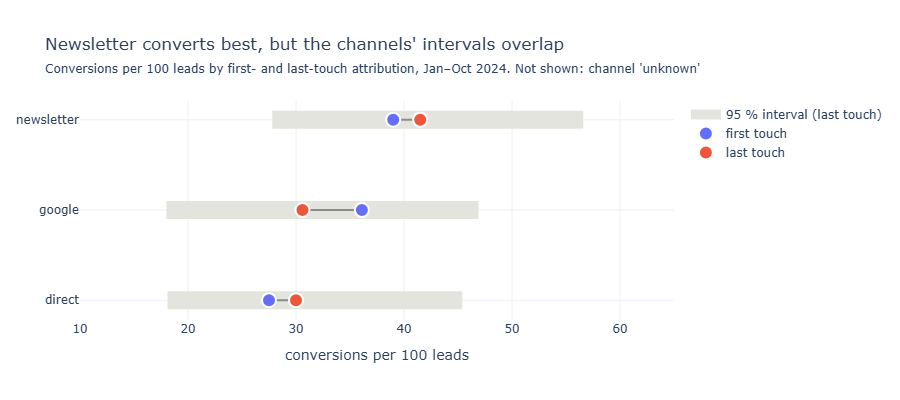

In [8]:
MODELS = {
    "first touch": ("first_touch_conversions", "first_touch_rate_pct"),
    "last touch": ("conversions", "conversion_rate_pct"),
}
MODEL_COLORS = {"first touch": "#636efa", "last touch": "#EF553B"}


def by_model(table: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    """One row per key and attribution model, with the conversions and the rate under that model."""
    return pd.concat(
        [
            table[keys].assign(model=model, conversions=table[count], rate_pct=table[rate])
            for model, (count, rate) in MODELS.items()
        ],
        ignore_index=True,
    )


# One row per channel. The grey band is the 95 % interval of the last-touch rate. On it, a dot per
# attribution model, joined by a line: its length shows how much the model moves the channel.
known_channels = channels[channels["channel"] != "unknown"].sort_values("conversion_rate_pct")
rates = by_model(known_channels, ["channel", "leads"])
band = known_channels[["channel", "low_pct", "high_pct"]].melt(
    id_vars="channel", value_name="rate_pct"
)

fig = px.line(band, x="rate_pct", y="channel", line_group="channel")
fig.update_traces(
    line={"color": "#e4e4de", "width": 18},
    hoverinfo="skip",
    name="95 % interval (last touch)",
    showlegend=False,
)
fig.data[0].showlegend = True
links = px.line(rates, x="rate_pct", y="channel", line_group="channel")
links.update_traces(line={"color": "#8c8c84", "width": 2}, hoverinfo="skip", showlegend=False)
dots = px.scatter(
    rates,
    x="rate_pct",
    y="channel",
    color="model",
    color_discrete_map=MODEL_COLORS,
    custom_data=["conversions", "leads"],
)
dots.update_traces(
    marker={"size": 14, "line": {"width": 2, "color": "white"}},
    hovertemplate=(
        "%{fullData.name}: %{customdata[0]} of %{customdata[1]} leads (%{x:.1f} %)<extra></extra>"
    ),
)
fig.add_traces(links.data + dots.data)
fig.update_layout(
    title="Newsletter converts best, but the channels' intervals overlap",
    title_subtitle_text=(
        "Conversions per 100 leads by first- and last-touch attribution, Jan–Oct 2024. "
        "Not shown: channel 'unknown'"
    ),
    legend_title_text="",
    margin_t=100,
)
fig.update_xaxes(title="conversions per 100 leads", range=[10, 65])
fig.update_yaxes(title=None, categoryorder="array", categoryarray=list(known_channels["channel"]))
fig.show()

**Reading:** newsletter converts best (41.5 conversions per 100 leads), direct and google least (30.0 and 30.6).
But the intervals overlap widely (newsletter 28–57, google 18–47): with about 40 leads per channel, the ranking
can still change. Counted at the first touch, google moves up to 36.1: it opened both journeys that other channels
closed, the only 2 assists.

### 2.1 Lead-month cohorts

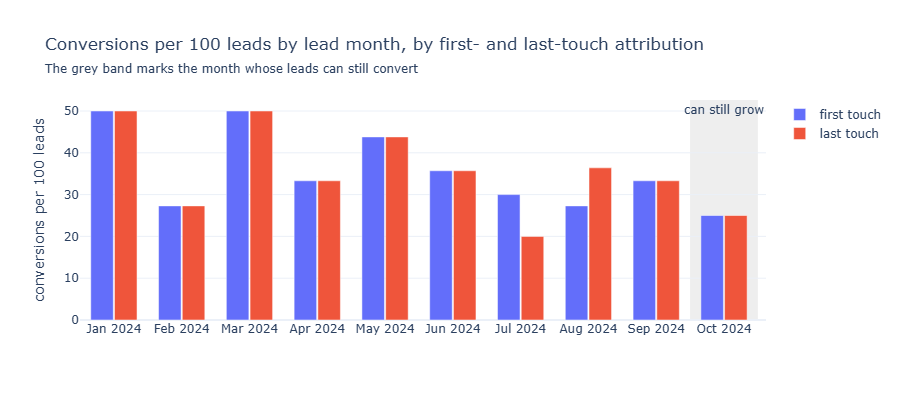

In [9]:
monthly = query("""
    select
        lead_month,
        is_complete,
        sum(leads) as leads,
        sum(conversions) as conversions,
        round(100.0 * sum(conversions) / sum(leads), 1) as conversion_rate_pct,
        sum(first_touch_conversions) as first_touch_conversions,
        round(100.0 * sum(first_touch_conversions) / sum(leads), 1) as first_touch_rate_pct
    from agg_lead_conversions_monthly
    group by lead_month, is_complete
    order by lead_month
""")
months = by_model(monthly, ["lead_month", "leads"])
months["month"] = months["lead_month"].dt.strftime("%b %Y")

fig = px.bar(
    months,
    x="month",
    y="rate_pct",
    color="model",
    color_discrete_map=MODEL_COLORS,
    barmode="group",
    custom_data=["conversions", "leads"],
    title="Conversions per 100 leads by lead month, by first- and last-touch attribution",
    labels={"month": "", "rate_pct": "conversions per 100 leads", "model": ""},
)
fig.update_traces(
    hovertemplate=(
        "%{fullData.name}: %{customdata[0]} of %{customdata[1]} leads (%{y:.1f} %)<extra></extra>"
    )
)
# A grey band marks the months whose leads can still convert
for position in monthly.index[~monthly["is_complete"]]:
    fig.add_vrect(
        x0=position - 0.5,
        x1=position + 0.5,
        fillcolor="#eeeeee",
        line_width=0,
        layer="below",
        annotation_text="can still grow",
        annotation_position="top",
    )
fig.update_layout(
    title_subtitle_text="The grey band marks the month whose leads can still convert",
    bargap=0.3,
    bargroupgap=0.05,
    margin_t=100,
)
fig.show()

**Reading:** the lead months swing between 20 and 50 conversions per 100 leads, with 6–20 leads each and no
trend. October has the most leads (20) and a low rate (25), but its leads can still convert. The two attribution
models differ only in July and August: the journey `google > newsletter` opened in July and closed in August.

## 3. Which conversions last, and what are they worth?

A conversion only pays if the contract lasts. Per channel: what became of the conversions (from the lead table),
and what a lead is worth in active premium (from the monthly table):

In [10]:
scorecard = query("""
    with outcomes as (
        select
            source as channel,
            count(*) as leads,
            count_if(is_last_touch) as conversions,
            count_if(is_last_touch and contract_status = 'active') as active,
            count_if(is_last_touch and contract_status = 'pending') as pending,
            count_if(is_last_touch and contract_status = 'cancelled') as cancelled
        from mart_lead_conversions
        group by source
    ),

    value as (
        select
            source as channel,
            round(sum(active_premium) / sum(leads), 0) as active_premium_per_lead,
            round(sum(first_touch_active_premium) / sum(leads), 0) as by_first_touch
        from agg_lead_conversions_monthly
        group by source
    )

    select *
    from outcomes
    inner join value using (channel)
    order by active_premium_per_lead desc, channel
""")
scorecard["active_per_100_leads"] = (100 * scorecard["active"] / scorecard["leads"]).round(1)
scorecard = scorecard.join(wilson_interval(scorecard["active"], scorecard["leads"]))
scorecard

,channel,leads,conversions,active,pending,cancelled,active_premium_per_lead,by_first_touch,active_per_100_leads,low_pct,high_pct
0,newsletter,41,17,13,0,4,186,186,31.7,19.6,47.0
1,direct,40,12,9,0,3,146,146,22.5,12.3,37.5
2,google,36,11,4,2,5,86,86,11.1,4.4,25.3
3,unknown,2,1,0,0,1,0,0,0.0,0.0,65.8


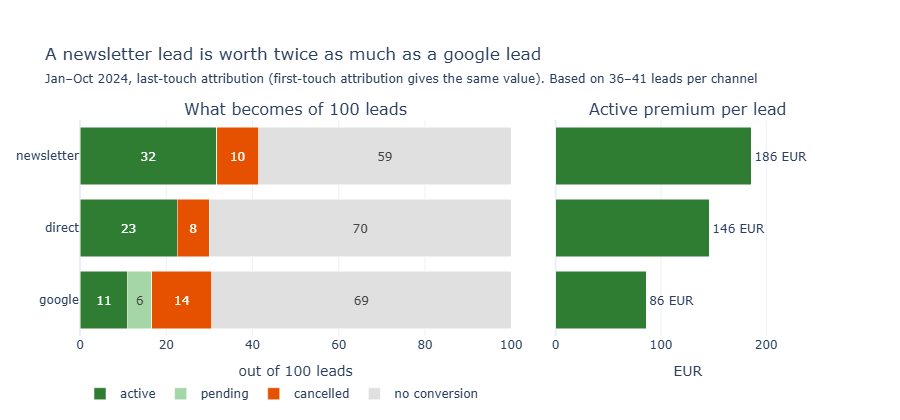

In [11]:
OUTCOMES = {
    "active": "#2e7d32",
    "pending": "#a5d6a7",
    "cancelled": "#e65100",
    "no_conversion": "#e0e0e0",
}
known = scorecard[scorecard["channel"] != "unknown"]
known = known.assign(no_conversion=known["leads"] - known["conversions"])

fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    column_widths=[0.62, 0.38],
    horizontal_spacing=0.06,
    subplot_titles=["What becomes of 100 leads", "Active premium per lead"],
)
# Left: the outcome of 100 leads, labelled where the segment is wide enough
for outcome, color in OUTCOMES.items():
    per_100_leads = (100 * known[outcome] / known["leads"]).astype(float)
    fig.add_trace(
        go.Bar(
            x=per_100_leads,
            y=known["channel"],
            orientation="h",
            name=outcome.replace("_", " "),
            marker_color=color,
            text=[f"{int(share + 0.5)}" if share >= 4 else "" for share in per_100_leads],
            textposition="inside",
            insidetextanchor="middle",
        ),
        row=1,
        col=1,
    )
# Right: what a lead is worth
fig.add_trace(
    go.Bar(
        x=known["active_premium_per_lead"],
        y=known["channel"],
        orientation="h",
        marker_color=OUTCOMES["active"],
        text=[f"{euros:,.0f} EUR" for euros in known["active_premium_per_lead"]],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.update_layout(
    barmode="stack",
    title="A newsletter lead is worth twice as much as a google lead",
    title_subtitle_text=(
        "Jan–Oct 2024, last-touch attribution (first-touch attribution gives the same value). "
        "Based on 36–41 leads per channel"
    ),
    legend={"orientation": "h", "y": -0.2, "traceorder": "normal"},
    margin_t=120,
    height=420,
)
fig.update_yaxes(categoryorder="array", categoryarray=list(known["channel"])[::-1])
fig.update_xaxes(title="out of 100 leads", range=[0, 100], row=1, col=1)
fig.update_xaxes(
    title="EUR", range=[0, known["active_premium_per_lead"].max() * 1.35], row=1, col=2
)
fig.show()

**Reading:** out of 100 leads, newsletter ends in 32 active conversions, direct in 23, google in 11. Google
converts as often as direct, but 5 of its 11 conversions are cancelled and 2 are pending. That decides the value:
a newsletter lead brings 186 EUR of active premium, a direct lead 146 EUR, a google lead 86 EUR.

This is the strongest signal in the data: the intervals of the active conversions barely overlap (google 4–25
per 100 leads, newsletter 20–47). First-touch attribution gives the same values, because both journeys with two
touchpoints ended in a cancelled contract. The status is today's; when a contract was cancelled is not in the
data.

### 3.1 And by vertical?

In [12]:
query("""
    with kpis as (
        select
            vertical,
            sum(leads) as leads,
            sum(conversions) as conversions,
            round(100.0 * sum(conversions) / sum(leads), 1) as conversion_rate_pct,
            round(sum(active_premium) / sum(leads), 0) as active_premium_per_lead
        from agg_lead_conversions_monthly
        group by vertical
    ),

    conversions as (
        select
            vertical,
            round(100.0 * count_if(contract_status = 'active') / count(*), 1) as still_active_pct,
            round(avg(premium) filter (where contract_status = 'active'), 0) as avg_active_premium
        from mart_lead_conversions
        where is_last_touch
        group by vertical
    )

    select *
    from kpis
    left join conversions using (vertical)
    order by active_premium_per_lead desc, vertical
""")

,vertical,leads,conversions,conversion_rate_pct,active_premium_per_lead,still_active_pct,avg_active_premium
0,unknown,2,1,50.0,216,100.0,432
1,haushalt,41,15,36.6,143,73.3,585
2,leben,44,14,31.8,143,57.1,788
3,auto,32,11,34.4,124,54.5,660


**Reading:** the verticals even out. Leben converts least (31.8 per 100 leads), but its active contracts carry
the largest premiums (788 EUR on average), so a leben lead is worth as much as a haushalt lead (143 EUR). Auto
keeps the fewest of its conversions (54.5 % still active) and is worth the least (124 EUR). The `unknown` row
stands for 2 leads.

## 4. What happens after the conversion?

The customer table (`agg_customers`) has one row per customer. At a glance, and the customers with the highest
active premium:

In [13]:
query("""
    with ranked as (
        select
            total_active_premium,
            row_number() over (order by total_active_premium desc nulls last, customer_email)
                as rank
        from agg_customers
        where has_active_contract
    ),

    concentration as (
        select
            round(
                100.0 * sum(total_active_premium) filter (where rank <= 5)
                / sum(total_active_premium),
                1
            ) as top_5_share_pct,
            round(
                100.0 * sum(total_active_premium) filter (where rank <= 10)
                / sum(total_active_premium),
                1
            ) as top_10_share_pct
        from ranked
    )

    select
        count(*) as customers,
        count_if(conversions > 0) as converted,
        count_if(has_active_contract) as with_active_contract,
        count_if(conversions > 1) as with_several_conversions,
        sum(total_active_premium) as total_active_premium,
        any_value(top_5_share_pct) as top_5_share_pct,
        any_value(top_10_share_pct) as top_10_share_pct
    from agg_customers
    cross join concentration
""")

,customers,converted,with_active_contract,with_several_conversions,total_active_premium,top_5_share_pct,top_10_share_pct
0,88,41,24,7,17438.69,41.6,67.1


In [14]:
query("""
    select customer_email, leads, conversions, total_active_premium, has_active_contract
    from agg_customers
    order by total_active_premium desc nulls last, customer_email
    limit 8
""")

,customer_email,leads,conversions,total_active_premium,has_active_contract
0,mia.berger@gmail.com,4,3,2043.92,True
1,leon.aigner@aon.at,3,2,1387.57,True
2,sophie.aigner@hotmail.com,3,1,1359.55,True
3,julia.brunner@hotmail.com,1,1,1299.57,True
4,paul.winkler@aon.at,1,1,1159.06,True
5,paul.aigner@gmail.com,1,1,999.13,True
6,hannah.fuchs@gmx.at,1,2,894.41,True
7,paul.fuchs@outlook.com,1,1,870.57,True


**Reading:** 41 of the 88 customers converted, and 24 hold an active contract today, with 17,438.69 EUR of annual
net premium in total. The value is concentrated: the top 5 customers hold 41.6 % of it, the top 10 hold 67.1 %.
hannah.fuchs@gmx.at is on the list because the customer view counts all 50 contracts: her active contract names
no valid lead, so the lead table does not have it.

### 4.1 The customer lifecycle

Every customer in one flow: the channel of the first touchpoint, whether a conversion followed, whether a new
journey started after it, and whether it converted again.

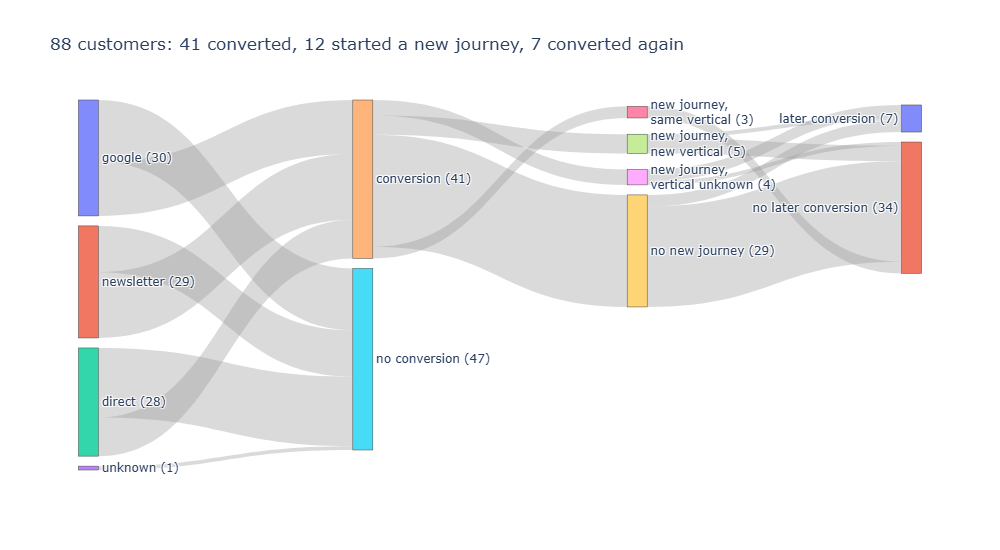

In [15]:
lifecycle = query("""
    select
        acquisition_source as channel,
        case when conversions > 0 then 'conversion' else 'no conversion' end as first_conversion,
        case
            when conversions = 0 then null
            when not returned_after_contract then 'no new journey'
            when return_vertical = 'same' then 'new journey, same vertical'
            when return_vertical = 'new' then 'new journey, new vertical'
            else 'new journey, vertical unknown'
        end as after_first_conversion,
        case
            when conversions > 1 then 'later conversion'
            when conversions = 1 then 'no later conversion'
        end as later_conversion,
        count(*) as customers
    from agg_customers
    group by all
""")

# Flows between neighbouring stages; a customer without a conversion leaves after the second stage
stages = ["channel", "first_conversion", "after_first_conversion", "later_conversion"]
links = pd.concat(
    [
        lifecycle.dropna(subset=[start, end])
        .groupby([start, end], as_index=False)["customers"]
        .sum()
        .set_axis(["source", "target", "customers"], axis=1)
        for start, end in zip(stages, stages[1:], strict=False)
    ],
    ignore_index=True,
)

# One column per stage, the nodes of a stage stacked from the top in a fixed order, each labelled
# with the customers it holds (what flows in, or what flows out for the first stage)
order = [
    "google", "newsletter", "direct", "unknown",
    "conversion", "no conversion",
    "new journey, same vertical", "new journey, new vertical", "new journey, vertical unknown",
    "no new journey",
    "later conversion", "no later conversion",
]
held = (
    links.groupby("target")["customers"].sum()
    .combine(links.groupby("source")["customers"].sum(), max, fill_value=0)
)
stage_of = {value: i for i, stage in enumerate(stages) for value in lifecycle[stage].dropna()}
nodes = pd.DataFrame({"node": [node for node in order if node in held.index]})
nodes["customers"] = nodes["node"].map(held)
nodes["stage"] = nodes["node"].map(stage_of)

GAP = 6  # space between two nodes, in customers
rank = nodes.groupby("stage").cumcount()
top = nodes.groupby("stage")["customers"].cumsum() - nodes["customers"] + rank * GAP
height = (nodes.groupby("stage")["customers"].sum() + nodes.groupby("stage").size() * GAP).max()
nodes["y"] = 0.02 + 0.96 * (top + nodes["customers"] / 2) / height
nodes["x"] = 0.01 + 0.98 * nodes["stage"] / (len(stages) - 1)
index = {node: i for i, node in enumerate(nodes["node"])}
# Two-line labels for "new journey, ...", so they do not run into the labels of the last stage
labels = [
    f"{node.replace(', ', ',<br>')} ({n})"
    for node, n in zip(nodes["node"], nodes["customers"], strict=True)
]

fig = go.Figure(
    go.Sankey(
        arrangement="snap",
        node={"label": labels, "x": nodes["x"], "y": nodes["y"], "pad": 10},
        link={
            "source": links["source"].map(index),
            "target": links["target"].map(index),
            "value": links["customers"],
            "color": "rgba(150, 150, 150, 0.35)",
        },
    )
)
fig.update_layout(
    title="88 customers: 41 converted, 12 started a new journey, 7 converted again",
    width=1000,
    height=550,
)
fig.show()

**Reading:** of 88 customers, 41 converted; newsletter brought the most (17 of the 29 customers whose first
touchpoint it was). After the first conversion, 12 started a new journey: 5 in a new vertical (interest in a
second product), 3 in the same vertical, and 4 in a vertical that cannot be told, because their first conversion
names no valid lead. 7 customers converted again.

### 4.2 When and how do customers come back?

In [16]:
query("""
    select
        return_vertical,
        count(*) as customers,
        median(days_to_return) as median_days,
        min(days_to_return) as fastest_days,
        max(days_to_return) as slowest_days,
        count_if(return_source = 'google') as via_google,
        count_if(return_source = 'newsletter') as via_newsletter,
        count_if(return_source = 'direct') as via_direct
    from agg_customers
    where returned_after_contract
    group by return_vertical
    order by customers desc, return_vertical
""")

,return_vertical,customers,median_days,fastest_days,slowest_days,via_google,via_newsletter,via_direct
0,new,5,27,17,166,2,1,2
1,unknown,4,24,13,97,2,2,0
2,same,3,52,39,63,0,1,2


**Reading:** the 12 customers came back 13 to 166 days after their first conversion: in a new vertical after 27
days (median), in the same vertical after 52. They came back through all three channels, 4 through each.

## 5. What this means

Signals to test with more data, not decisions:
- **Judge channels by what lasts, not by the conversion rate.** Per lead, newsletter brings more than twice the
  active premium of google. That value is also the upper limit of what a lead may cost.
- **Look into google's cancellations.** 5 of its 11 conversions are cancelled, 2 are pending. The contract
  snapshot (Task 4) records from now on when a contract is cancelled.
- **Follow up with customers who compare repeatedly:** they convert far more often.
- **Offer a second product about four weeks after the conversion:** that is when customers came back for another
  vertical.
- **Close the data gap:** the 9 contracts without a valid lead are missing from every channel and vertical above
  (issue 1 in the README).